In [1]:
import psutil
import platform
import os
env_name = os.environ.get('CONDA_DEFAULT_ENV')
print("当前 conda 环境名：", env_name)
print(platform.system()) # 操作系统名称
print(platform.release()) # 操作系统版本
print(platform.machine()) # 计算机架构
print(platform.processor()) # 处理器类型
# CPU 信息
print(psutil.cpu_count()) # CPU 核数
print(psutil.cpu_freq()) # CPU 频率
# 内存信息
print(psutil.virtual_memory()) # 内存总量、可用内存、已用内存等

当前 conda 环境名： database1
Windows
11
AMD64
Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
16
scpufreq(current=2200.0, min=0.0, max=2200.0)
svmem(total=16780759040, available=2348691456, percent=86.0, used=14432067584, free=2348691456)


In [5]:
# -------------------------- 通用配置：解决中文乱码 --------------------------
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 黑体
plt.rcParams["axes.unicode_minus"] = False   # 解决负号显示问题

2.1 理论计算题
已知向量 a = [2, −1, 3]⊤，b = [1, 4, −2]⊤，矩阵
A =
[
1 0 2
-1 3 1]
, B =
[
2 1
0 -1
3 2]
计算：
1. 向量点积 a · b；
2. 矩阵乘法 A × B（结果矩阵的形状？）；
3. 向量 a 的 Frobenius 范数。

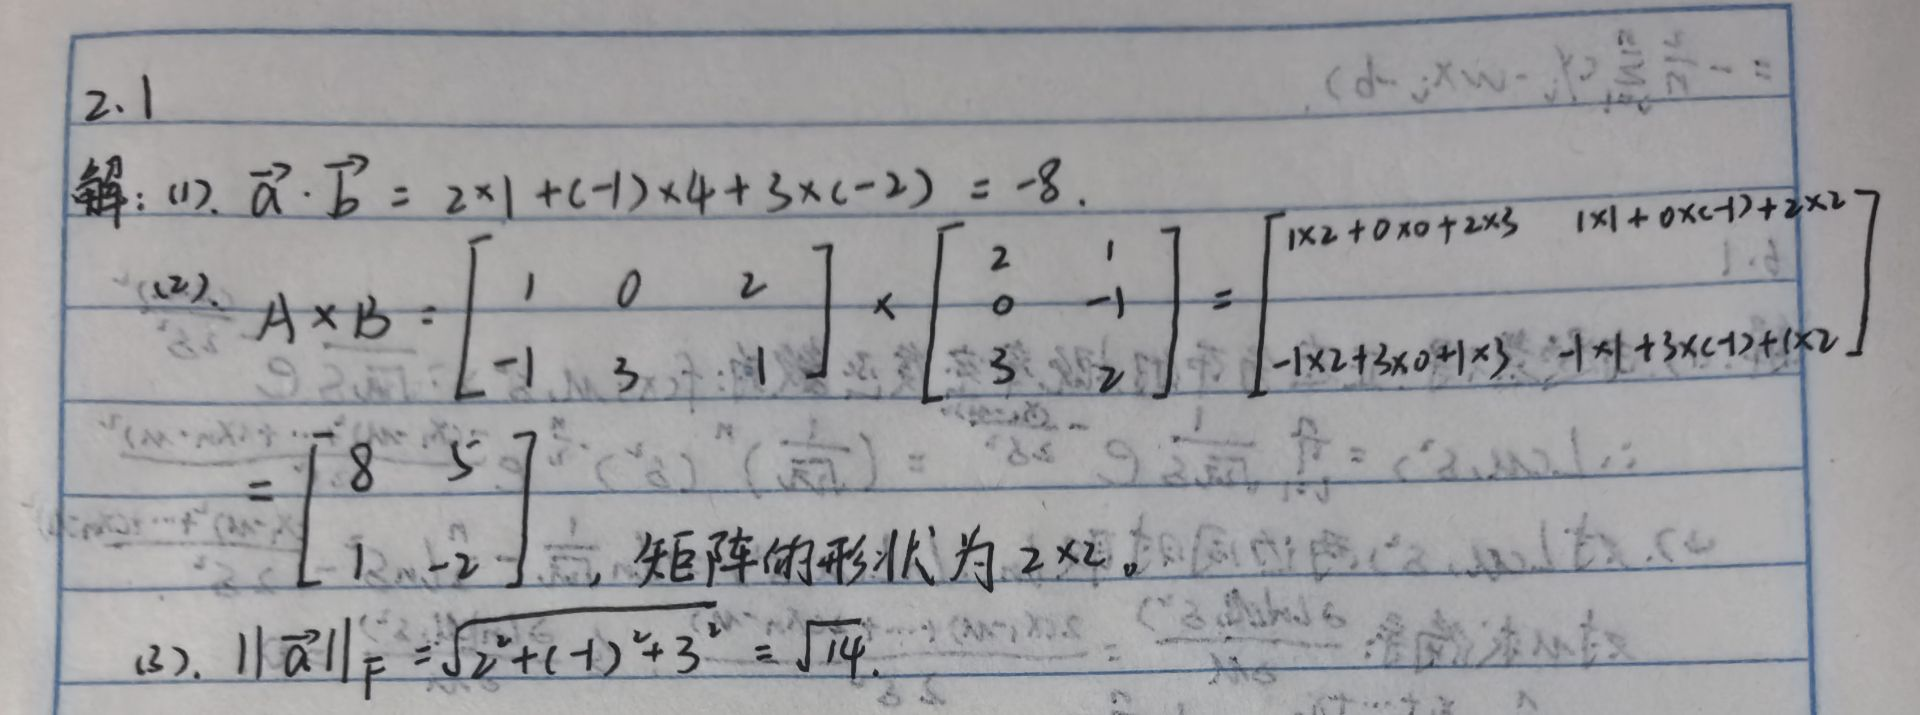

2.2 编程题：
使用 NumPy（或 MXNet / PyTorch/TensorFlow）完成以下任务：
1. 创建一个形状为 3 × 4 的随机矩阵 X，元素服从标准正态分布。
2. 创建一个形状为 4 × 2 的全 1 矩阵 Y 。
3. 计算矩阵乘法 Z = X × Y 。
4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素。
5. 计算 Z 的 Frobenius 范数。

In [3]:
import numpy as np
# 1. 创建 3×4 标准正态随机矩阵 X
X = np.random.randn(3, 4)
print("3×4 标准正态随机矩阵 X")
print(X)
# 2. 创建 4×2 全1矩阵 Y
Y = np.ones((4, 2))
print("4×2 全1矩阵 Y")
print(Y)
# 3. 矩阵乘法 Z = X @ Y
Z = X @ Y
print("矩阵乘积 Z = X @ Y")
print(Z)
# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素
print("Z[0,1]（第一行第二列） =", Z[0, 1])
print("Z[1,:]（第二行所有元素） =", Z[1, :])
# 5. 计算 Z 的 Frobenius 范数
fro_Z = np.linalg.norm(Z, 'fro')
print("Z的F范数 =", fro_Z)

3×4 标准正态随机矩阵 X
[[-0.69991679 -0.18246846 -0.1911945  -1.55825579]
 [-0.51621518 -1.12751055 -0.49775388 -0.37359287]
 [ 0.2863154   1.18409777 -0.24615848  0.08915161]]
4×2 全1矩阵 Y
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
矩阵乘积 Z = X @ Y
[[-2.63183554 -2.63183554]
 [-2.51507248 -2.51507248]
 [ 1.31340631  1.31340631]]
Z[0,1]（第一行第二列） = -2.631835536875649
Z[1,:]（第二行所有元素） = [-2.51507248 -2.51507248]
Z的F范数 = 5.4730583820462755


3.1 理论计算题
某疾病在人群中的患病率为 0.1%。现有一种检测方法：
• 若患病，检测呈阳性的概率为 99%（灵敏度）；
• 若未患病，检测呈阳性的概率为 2%（假阳性率）。
一个人检测结果为阳性，求他真正患病的概率（使用贝叶斯公式）

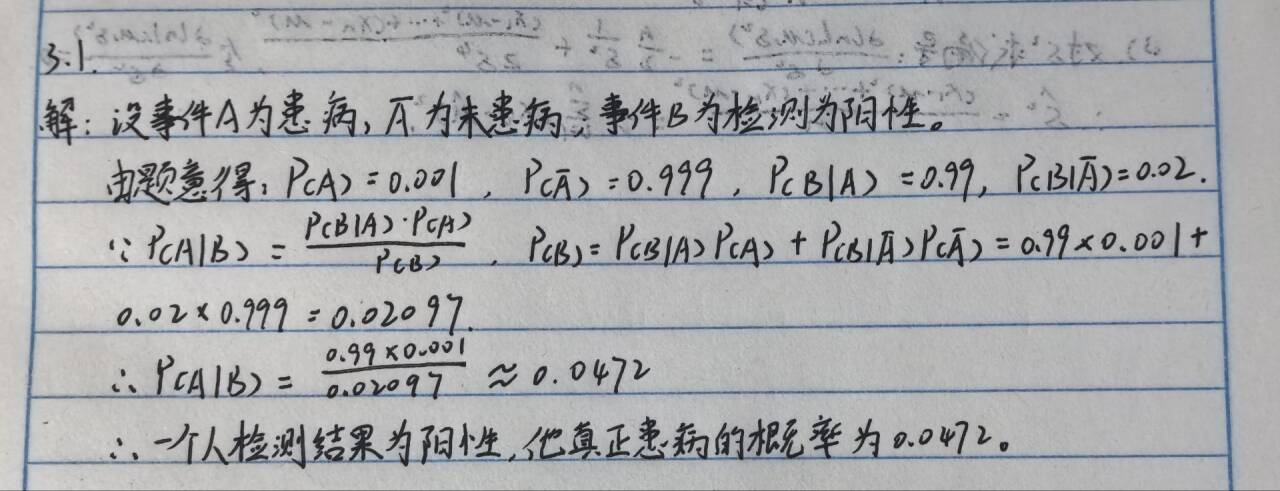

3.2 编程题
用 Python 模拟中心极限定理：
1. 生成 n = 10000 个服从均匀分布 U(0, 1) 的随机变量，重复 m = 1000
次，每次计算这 n 个变量的均值。
2. 绘制这 1000 个均值的直方图，并叠加理论正态分布的概率密度曲线。
3. 计算这些均值的实际方差。

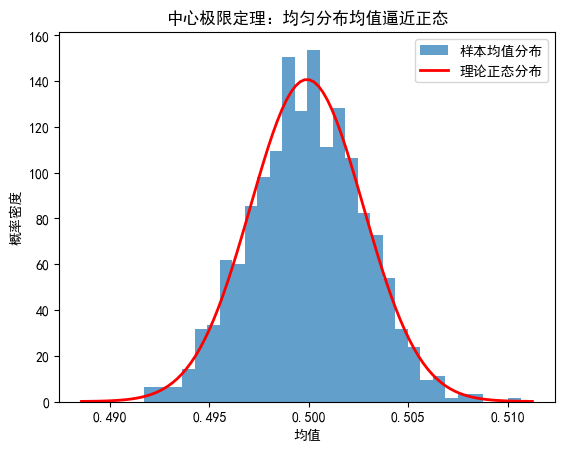

均值的方差 = 8.037106944688119e-06


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

n = 10000
m = 1000
means = [np.random.uniform(0, 1, n).mean() for _ in range(m)]

# 绘制直方图（密度模式）
plt.hist(means, bins=30, density=True, alpha=0.7, label='样本均值分布')
mu, std = np.mean(means), np.std(means)
x = np.linspace(mu - 4*std, mu + 4*std, 100)
plt.plot(x, norm.pdf(x, mu, std), 'r-', lw=2, label='理论正态分布')
plt.title("中心极限定理：均匀分布均值逼近正态")
plt.xlabel("均值")
plt.ylabel("概率密度")
plt.legend()
plt.show()

# 实际方差
print("均值的方差 =", np.var(means))

4.1 理论计算题
给定函数 z = (w1x1 + w2x2 − y)
2，其中 x1 = 2, x2 = 1, y = 3 为常数，
w1, w2 为变量。
1. 分别计算 ∂w
∂z
1 和 ∂w
∂z
2 的表达式。
2. 若当前 w1 = 0.5, w2 = 1，计算梯度值。

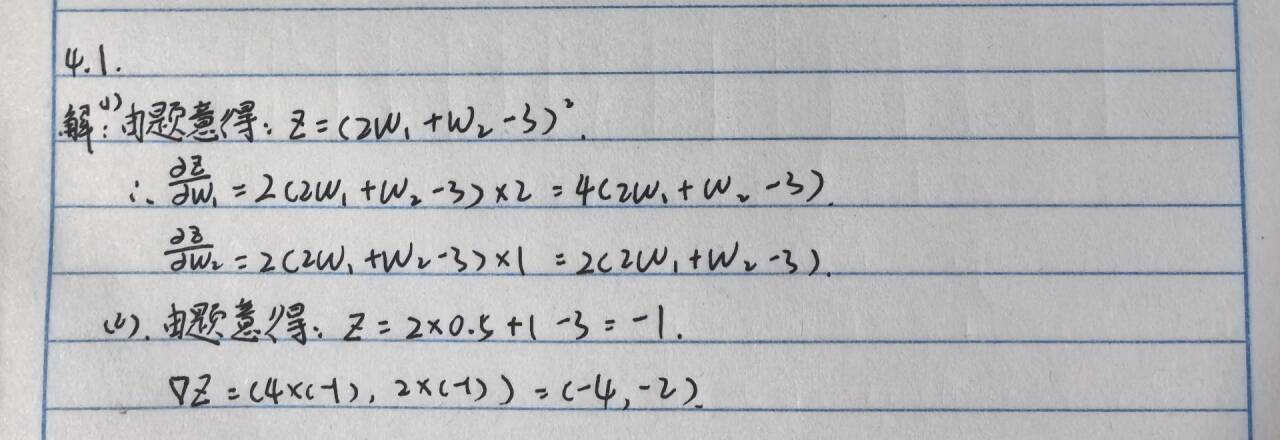

4.2 编程题
手动实现一个简单计算图的反向传播：
1. 定义前向计算：输入 x，经过 a = x · w1，b = a + w2，输出 L = b^2。
2. 给定 x = 2, w1 = 1.5, w2 = 0.5，计算前向结果。
3. 手动（按链式法则）计算损失 L 对 w1, w2 的梯度，并验证与自动微分
工具（如 torch.autograd）的结果是否一致。

In [8]:
import torch

# 前向（普通数值计算）
x, w1, w2 = 2, 1.5, 0.5
a = x * w1
b = a + w2
L = b ** 2
print("前向 L =", L) 

# 手动反向传播
dL_db = 2 * b
db_dw2 = 1
db_da = 1
da_dw1 = x

dL_dw1 = dL_db * db_da * da_dw1
dL_dw2 = dL_db * db_dw2
print("手动梯度 dw1={}, dw2={}".format(dL_dw1, dL_dw2))

# PyTorch 自动微分验证
x = torch.tensor(2.0, requires_grad=False)
w1 = torch.tensor(1.5, requires_grad=True)
w2 = torch.tensor(0.5, requires_grad=True)
a = x * w1
b = a + w2
L = b ** 2
L.backward()
print("torch autograd dw1={}, dw2={}".format(w1.grad.item(), w2.grad.item()))

前向 L = 12.25
手动梯度 dw1=14.0, dw2=7.0
torch autograd dw1=14.0, dw2=7.0


5.1 理论计算题
考虑线性回归模型 y = wx + b，使用均方误差损失
L =
1/n
n∑
i=1
(yi − (wxi + b))2
推导损失对 w 和 b 的偏导数表达式（用求和形式）。

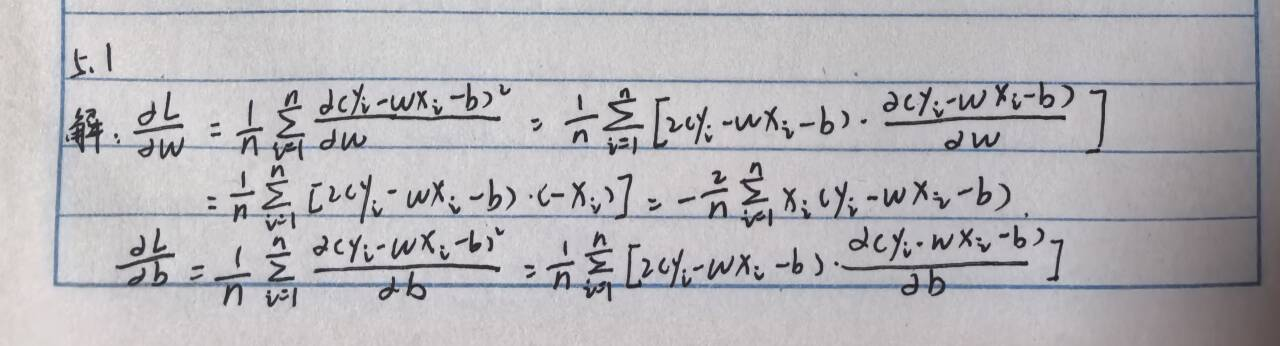
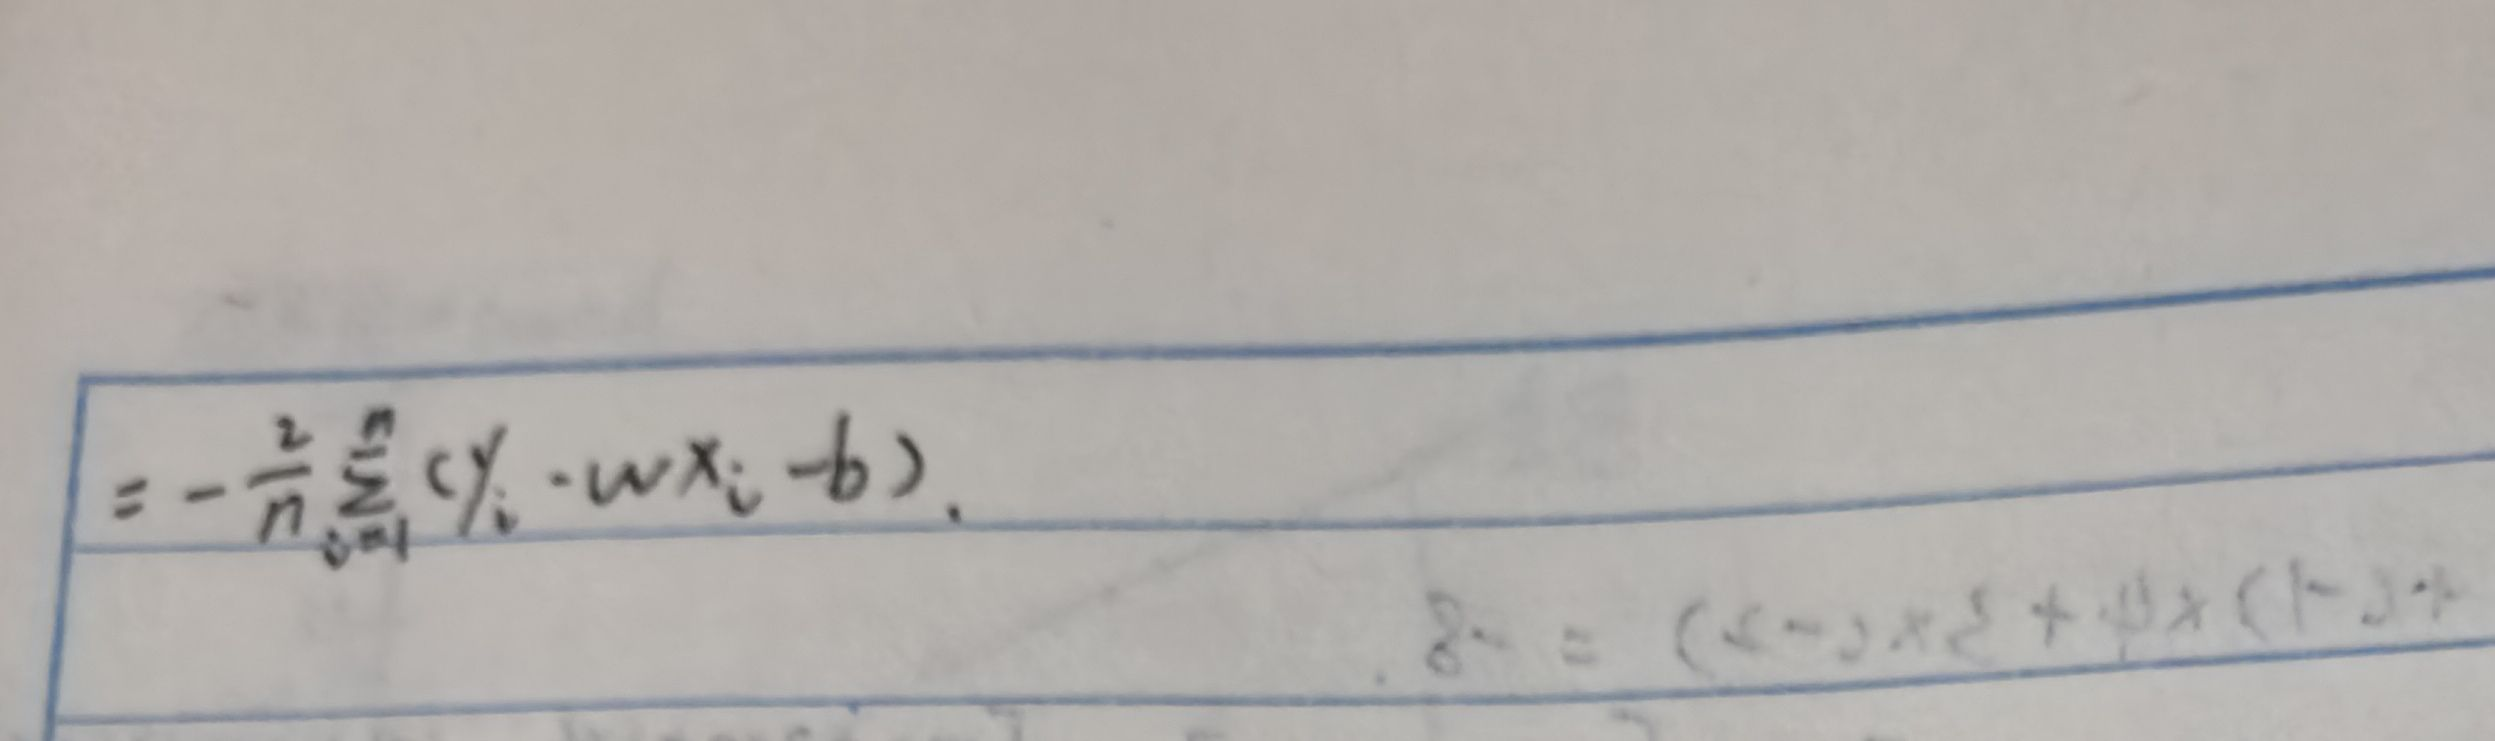

5.2 编程题
从零实现 softmax 回归对手写数字（MNIST）进行分类：
1. 使用 sklearn.datasets.load_digits() 或自己加载 MNIST 子集。
2. 将图像展平为向量，对标签进行 one‑hot 编码。
3. 实现 softmax 函数、交叉熵损失函数。
4. 使用小批量随机梯度下降（批量大小 32，学习率 0.1）训练模型 50 个
epoch。
5. 输出测试集上的准确率。

In [11]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# 加载数据并归一化
data = load_digits()
X = data.data / 16.0
y = data.target
n_classes = 10

# One-hot 编码
def one_hot(y, n_classes):
    out = np.zeros((len(y), n_classes))
    out[np.arange(len(y)), y] = 1
    return out

y_one = one_hot(y, n_classes)
X_train, X_test, y_train, y_test = train_test_split(X, y_one, test_size=0.2, random_state=42)

# Softmax
def softmax(z):
    ex = np.exp(z - np.max(z, axis=1, keepdims=True))
    return ex / np.sum(ex, axis=1, keepdims=True)

# 交叉熵损失
def cross_entropy(y_pred, y_true):
    return -np.mean(y_true * np.log(y_pred + 1e-8))

# 初始化参数
W = np.random.randn(64, 10) * 0.01
b = np.zeros(10)
lr = 0.1
epochs = 50
batch_size = 32

# 训练
for epoch in range(epochs):
    for i in range(0, len(X_train), batch_size):
        Xb = X_train[i:i+batch_size]
        yb = y_train[i:i+batch_size]
        logits = Xb @ W + b
        pred = softmax(logits)
        
        # 梯度
        dW = Xb.T @ (pred - yb) / len(Xb)
        db = np.mean(pred - yb, axis=0)
        
        W -= lr * dW
        b -= lr * db

# 计算准确率
def accuracy(X, y_true):
    pred = softmax(X @ W + b)
    return np.mean(np.argmax(pred, axis=1) == np.argmax(y_true, axis=1))

acc = accuracy(X_test, y_test)
print(f"Softmax 测试准确率 = {acc:.4f}")

Softmax 测试准确率 = 0.9611


6.1 理论计算题
假设样本 x1, x2, . . . , xn 独立同分布于正态分布 N (µ, σ2
)。
1. 写出似然函数 L(µ, σ2
)。
2. 证明：µ 的最大似然估计为 µˆ = n
1 ∑n
i=1 xi。
3. 证明：σ
2 的最大似然估计为 σˆ
2 = n
1 ∑n
i=1(xi − µˆ)
2。

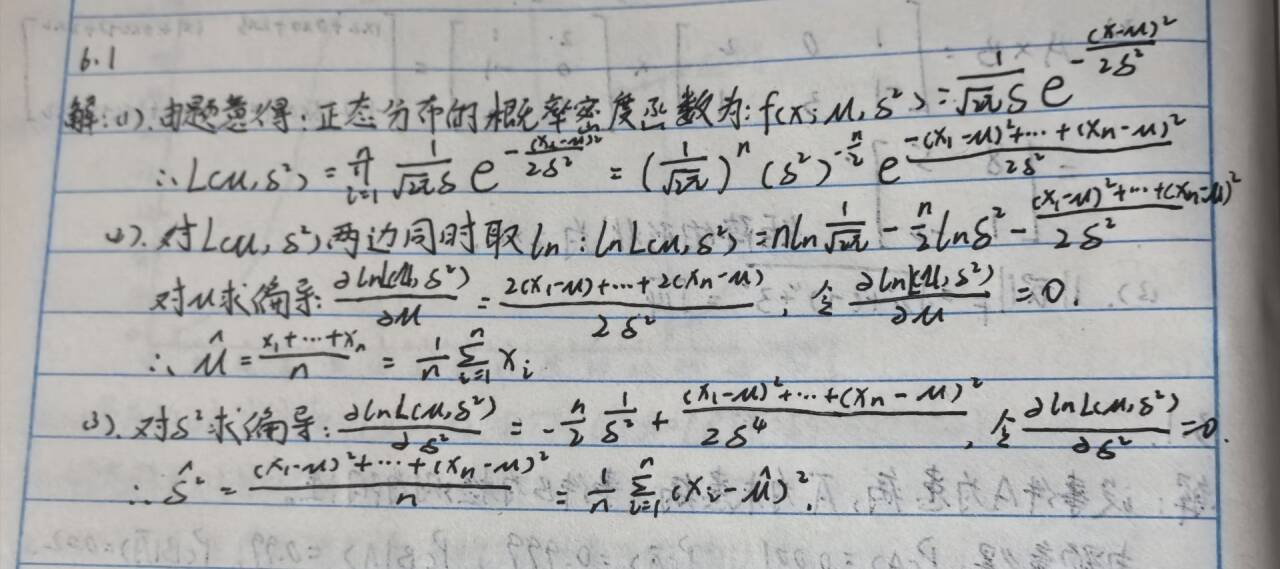

6.2 编程题
实现二分类逻辑回归模型（不使用深度学习框架的高阶 API）：
1. 生成两类线性可分的数据：每类 200 个样本，特征维度为 2。
2. 定义 sigmoid 函数和二元交叉熵损失。
3. 使用梯度下降法（学习率 0.1，迭代 1000 次）学习参数 w, b。
4. 绘制决策边界，并计算模型在测试集（新生成 100 个样本）上的分类
准确率。

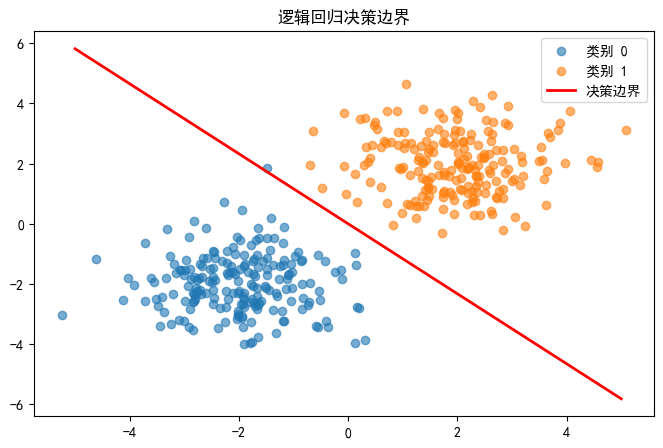

逻辑回归测试准确率 = 1.0000


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 生成线性可分数据
np.random.seed(42)
n = 200
X0 = np.random.randn(n, 2) + np.array([-2, -2])
X1 = np.random.randn(n, 2) + np.array([2, 2])
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n), np.ones(n)])

# Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 二元交叉熵
def binary_loss(y_pred, y_true):
    return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

# 训练
w = np.zeros(2)
b = 0.0
lr = 0.1
steps = 1000

#训练逻辑回归
for _ in range(steps):
    yp = sigmoid(X @ w + b)
    dw = X.T @ (yp - y) / len(y)
    db = np.mean(yp - y)
    w -= lr * dw
    b -= lr * db

# 绘制决策边界
plt.figure(figsize=(8, 5))
plt.scatter(X0[:, 0], X0[:, 1], label="类别 0", alpha=0.6)
plt.scatter(X1[:, 0], X1[:, 1], label="类别 1", alpha=0.6)
x_line = np.linspace(-5, 5, 100)
y_line = -(w[0] * x_line + b) / w[1]
plt.plot(x_line, y_line, 'r-', lw=2, label="决策边界")
plt.legend()
plt.title("逻辑回归决策边界")
plt.show()

# 测试集评估
X_test0 = np.random.randn(50, 2) + [-2, -2]
X_test1 = np.random.randn(50, 2) + [2, 2]
X_test = np.vstack([X_test0, X_test1])
y_test = np.hstack([np.zeros(50), np.ones(50)])

y_pred = sigmoid(X_test @ w + b) >= 0.5
test_acc = np.mean(y_pred == y_test)
print(f"逻辑回归测试准确率 = {test_acc:.4f}")